In [ ]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,END
from langchain_community.document_loaders import TextLoader, DirectoryLoader


In [45]:
loader = DirectoryLoader(r"C:\Users\mendh\Langchain-Langgraph\0-Dataingestion-parsing\data\text_files",loader_cls=TextLoader)
docs= loader.load()

In [46]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = splitter.split_documents(docs)
vectorstore = FAISS.from_documents(chunks,embedding=embeddings)
retriever = vectorstore.as_retriever()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [47]:
import os
from langchain_classic.chat_models import init_chat_model
from dotenv import load_dotenv
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = init_chat_model(model_provider="groq",model = "llama-3.1-8b-instant")

In [48]:
class RAGCoTState(BaseModel):
    question: str
    sub_steps: list[str]=[]
    retrieved_docs: List[Document] = []
    answer: str = ""

In [49]:
def plan_steps(state:RAGCoTState):
    prompt = f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    result = llm.invoke(prompt).content
    subqs = [line.strip("- ") for line in result.split("\n") if line.strip()]

    return state.model_copy(update={"sub_steps":subqs})

In [50]:
def generate_answer(state: RAGCoTState):
    context = f"\n\n".join([doc.page_content for doc in state.retrieved_docs])

    prompt = f""" you are answering complex question using reasoning and retrived documents.

    Question: {state.question}

Relevant information: {context}

Now Synthesize a well-reasoned final answer
"""
    
    result = llm.invoke(prompt).content.strip()

    return state.model_copy(update = {"answer":result})

def retrieve_per_step(state: RAGCoTState):
    all_docs= []
    for sub in state.sub_steps:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    
    return state.model_copy(update = {"retriever_docs":all_docs})

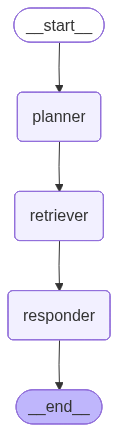

In [51]:
builder = StateGraph(RAGCoTState)
builder.add_node("planner",plan_steps)
builder.add_node("retriever",retrieve_per_step)
builder.add_node("responder",generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner","retriever")
builder.add_edge("retriever","responder")
builder.add_edge("responder",END)

graph = builder.compile()
graph

In [52]:
query = "what are the different types of machine learning"

state = RAGCoTState(question=query)
final = graph.invoke(state)

print("Reasoning Steps:\n", final["sub_steps"])
print("Final answer:\n", final["answer"])


Reasoning Steps:
 ['Here are 3 reasoning steps to break down the question into different types of machine learning:', '**Step 1: Understanding the Basic Types of Machine Learning**', 'Machine learning can be broadly categorized into three basic types: Supervised Learning, Unsupervised Learning, and Reinforcement Learning.', '**Step 2: Breaking Down Each Type of Machine Learning**', '**Supervised Learning**: In this type of machine learning, the model is trained on labeled data, where the correct output is already known. The model learns to map inputs to outputs based on the labeled data. Examples of supervised learning include image classification, text classification, and regression analysis.', '**Unsupervised Learning**: In this type of machine learning, the model is trained on unlabeled data. The model learns to identify patterns and relationships in the data without any prior knowledge of the correct output. Examples of unsupervised learning include clustering, dimensionality reduc

In [67]:
from langchain.tools import tool
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun
from langchain_community.utilities.wikipedia import WikipediaAPIWrapper

api_wrapper = WikipediaAPIWrapper()
wiki_engine = WikipediaQueryRun(api_wrapper=api_wrapper)


from langchain_core.documents import Document

def wiki_search(state: RAGCoTState):
    """Node to retrieve information from wikipedia"""
    all_docs = []
    
    for sub in state.sub_steps:
        print(f"Using Wiki tool: query is: {sub}")
        result_text = wiki_engine.run(sub)
        
        # Wrap the string in a Document object to match the State schema
        doc = Document(page_content=result_text, metadata={"source": "wikipedia", "query": sub})
        all_docs.append(doc)
    
    return {"retrieved_docs": all_docs}




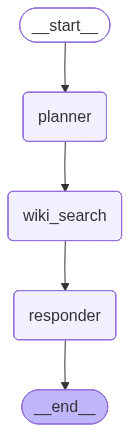

In [68]:
builder = StateGraph(RAGCoTState)
builder.add_node("planner",plan_steps)
builder.add_node("wiki_search",wiki_search)
builder.add_node("responder",generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner","wiki_search")
builder.add_edge("wiki_search","responder")
builder.add_edge("responder",END)

graph = builder.compile()
graph

In [69]:
query = "what are the different types of Reinforcement learning"

state = RAGCoTState(question=query)
final = graph.invoke(state)

print("Reasoning Steps:\n", final["sub_steps"])
print("Final answer:\n", final["answer"])


Using Wiki tool: query is: Here are 2-3 reasoning steps to break down the types of Reinforcement Learning:
Using Wiki tool: query is: **Step 1: Understanding the Basics of Reinforcement Learning**
Using Wiki tool: query is: Reinforcement Learning (RL) is a type of Machine Learning where an agent learns to take actions in an environment to maximize a reward signal. The agent learns through trial and error, by observing the outcome of its actions and adjusting its behavior accordingly.
Using Wiki tool: query is: **Step 2: Classifying Types of Reinforcement Learning**
Using Wiki tool: query is: There are several types of Reinforcement Learning, which can be broadly classified into three categories:
Using Wiki tool: query is: 1. **Model-Based Reinforcement Learning**: In this type of RL, the agent learns a model of the environment, which allows it to predict the consequences of its actions. This enables the agent to plan and optimize its behavior using the learned model.
Using Wiki tool: q